In [1]:
import pricing_driven_service_allocation as pdsa

# URLS
PRIME_INSTANCE_URL = "http://localhost:3000/api/v1/"
# Paths
TOPOLOGIES_DIR = "synthetic-dataset/synthetic-topologies"
RESULTS_DIR = "results"
DEVICES_EUA_DATASET_PATH = "eua-dataset/edge-servers/site.csv"
CLIENTS_EUA_DATASET_PATH = "eua-dataset/users/users-aus.csv"
EXPERIMENT_CONFIGURATION_PATH = "experiments/experiment_test.yml"
# Scenario containers
topologies = {}
demands = {}
filters = {}
results = {}
# Configuration
SEED = 42
UNLIMITED_VALUE = 100000000
VENDORS_TO_CONSIDER = ["Telstra", "Optus", "Vodafone", "Telecom", "Macquarie"]
OFFER_CONFIGURATION = {
    "global": {
        "group_percentages": {1: 40, 2: 30, 3: 30},
        "group_ranges": {1: (0, 12.5), 2: (12.5, 50), 3: (50, 100)},
    },
    "attributes": {
        "available_ram_gb": {
            "min": 1,
            "max": 128,
            "default_price": 0.5,
            "price_by_provider_group": {
                "OPTUS": {1: 1, 2: 0.15, 3: 0.005},
                "TELSTRA": {1: 1.3, 2: 0.12, 3: 0.003},
                "VODAFONE": {1: 1.5, 2: 0.18, 3: 0.001},
                "MACQUARIE": {1: 0.2, 2: 0.17, 3: 0.008},
                "TELECOM": {1: 0.7, 2: 0.14, 3: 0.004},
            },
            "local_distribution": {1: [(70, 0, 25), (30, 25, 100)]},
        },
        "available_storage_gb": {
            "min": 1,
            "max": 2000,  # gigabytes; adjust if you want very large storage nodes
            "default_price": 0.2,
            "price_by_provider_group": {
                "OPTUS": {1: 0.90, 2: 0.25, 3: 0.08},
                "TELSTRA": {1: 1.10, 2: 0.30, 3: 0.10},
                "VODAFONE": {1: 1.25, 2: 0.35, 3: 0.05},
                "MACQUARIE": {1: 0.50, 2: 0.20, 3: 0.09},
                "TELECOM": {1: 0.85, 2: 0.28, 3: 0.07},
            },
            "local_distribution": {
                # Conserva tu intención: muchos dispositivos con poco almacenamiento y unos pocos con más
                1: [(70, 0, 2), (30, 2, 25)]
            },
        },
        "available_cpu_cores": {
            "min": 1,
            "max": 64,
            "default_price": 15,
        },
        # Unidades equivalentes, coherentes con gpu_equivalent_units en demanda
        "available_gpu_units": {
            "min": 0,
            "max": 8,
            "default_price": 120,
            "price_by_provider_group": {
                "TELSTRA": {2: 130, 3: 150},
                "OPTUS": {3: 140},
            },
            "local_distribution": {
                1: [(85, 0, 25), (15, 25, 50)],
                2: [(60, 0, 50), (40, 50, 100)],
                3: [(30, 0, 50), (70, 50, 100)],
            },
        },
        "available_tpu_units": {
            "min": 0,
            "max": 4,
            "default_price": 200,
            "price_by_provider_group": {
                "TELSTRA": {3: 240},
                "OPTUS": {2: 210},
            },
            "local_distribution": {
                1: [(90, 0, 25), (10, 25, 50)],
                2: [(70, 0, 50), (30, 50, 100)],
                3: [(40, 0, 50), (60, 50, 100)],
            },
        },
        # Opcional: si luego quieres que el algoritmo también restrinja por ancho de banda
        "available_network_in_mbps": {
            "min": 10,
            "max": 10000,
            "default_price": 0.01,
            "local_distribution": {
                1: [(80, 0, 20), (20, 20, 100)],
                2: [(60, 20, 60), (40, 60, 100)],
                3: [(20, 60, 100), (80, 80, 100)],
            },
        },
        "available_network_out_mbps": {
            "min": 10,
            "max": 10000,
            "default_price": 0.01,
            "local_distribution": {
                1: [(80, 0, 20), (20, 20, 100)],
                2: [(60, 20, 60), (40, 60, 100)],
                3: [(20, 60, 100), (80, 80, 100)],
            },
        },
    },
    "device_types_by_group": {
        1: {"CAMERA": 35, "SENSOR": 35, "NETWORK_NODE": 30},
        2: {"COMPUTER": 60, "NETWORK_NODE": 40},
        3: {"DATA_CENTER": 100},
    },
}
RESOURCES_TO_CONSIDER = [
    key for key in OFFER_CONFIGURATION["attributes"].keys() if "network" not in key
]

In [2]:
import yaml
import os

# Load the YAML file
with open(os.path.join(EXPERIMENT_CONFIGURATION_PATH), 'r') as file:
  config_data = yaml.safe_load(file)
  
for scenario_size in config_data['experiments'].keys():
    for scenario_id in config_data['experiments'][scenario_size].keys():
        topology_offer = config_data['experiments'][scenario_size][scenario_id]['offer']
        # Check that all providers in the topology offer are in the vendors to consider
        providers_in_offer = [p.lower() for p in topology_offer['providers'].keys()]
        vendors_lower = [v.lower() for v in VENDORS_TO_CONSIDER]

        if not all(provider in vendors_lower for provider in providers_in_offer):
          raise ValueError(f"Some providers in topology {scenario_size}/{scenario_id} offer are not in VENDORS_TO_CONSIDER."
                   f"Providers in offer: {providers_in_offer}, "
                   f"Vendors to consider: {vendors_lower}")

In [3]:
import os
import shutil

# Create all defined paths if they do not exist
paths_to_create = [
  TOPOLOGIES_DIR,
]

for path in paths_to_create:
  if path and not os.path.exists(path):
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")
  elif path and os.path.exists(path):
    print(f"Directory already exists: {path}. Removing existing subfolders...")
    # Remove existing subfolders (including non-empty ones)
    for subfolder in os.listdir(path):
      subfolder_path = os.path.join(path, subfolder)
      if os.path.isdir(subfolder_path):
        shutil.rmtree(subfolder_path)
    print("Done!")
    

Directory already exists: synthetic-dataset/synthetic-topologies. Removing existing subfolders...
Done!


# 2. Filter EUA dataset

In this step, we will filter the EUA dataset to include only devices from which we can infer the vendor, usually throug their description. This is crucial for our analysis as it allows us to categorize devices and simulate exclusion and interoperability relationships among providers.

In addition, we will enrich the dataset with synthetic resources, unit prices, and device types. This enrichment is based on the OFFER_CONFIGURATION defined at the beginning of the notebook.

In [4]:
# Load dataset
devices_df = pdsa.dataset.load_devices_dataframe(DEVICES_EUA_DATASET_PATH)
# Filter devices from which vendor can be inferred
devices_df = pdsa.dataset.filter_devices_by_vendors(devices_df, VENDORS_TO_CONSIDER)
# Assign resources to devices based on the offer configuration
devices_df = pdsa.dataset.assign_device_resources(devices_df, OFFER_CONFIGURATION, SEED)

devices_df.head()

,latitude,longitude,elevation,provider,global_group,device_type,available_ram_gb,unit_price_available_ram_gb,available_storage_gb,unit_price_available_storage_gb,available_cpu_cores,unit_price_available_cpu_cores,available_gpu_units,unit_price_available_gpu_units,available_tpu_units,unit_price_available_tpu_units,available_network_in_mbps,unit_price_available_network_in_mbps,available_network_out_mbps,unit_price_available_network_out_mbps
device_id,,,,,,,,,,,,,,,,,,,,
10000002,-28.777660,114.634260,NaN,OPTUS,1,SENSOR,5,1.000,5,0.90,4,15.0,0,120.0,0,200.0,25,0.01,983,0.01
100001,-38.248652,144.605442,23.0,TELSTRA,1,NETWORK_NODE,12,1.300,9,1.10,6,15.0,0,120.0,0,200.0,130,0.01,239,0.01
10000114,-31.901910,152.533540,NaN,OPTUS,3,DATA_CENTER,95,0.005,1818,0.08,39,15.0,7,140.0,3,200.0,9296,0.01,9484,0.01
100002,-37.728550,145.222007,116.0,OPTUS,2,NETWORK_NODE,61,0.150,394,0.25,29,15.0,1,120.0,0,210.0,4437,0.01,2391,0.01
10000215,-32.981570,121.644400,NaN,TELSTRA,2,NETWORK_NODE,22,0.120,949,0.30,11,15.0,1,130.0,1,200.0,2270,0.01,2359,0.01


# 3. Topology Generation

In [5]:

for scenario_size in config_data['experiments'].keys():
    for scenario_id in config_data['experiments'][scenario_size].keys():
        topology_offer = config_data['experiments'][scenario_size][scenario_id]['offer']
        _, topology_id = pdsa.generators.topology(
                          lat = topology_offer['zone']['lat'],
                          long = topology_offer['zone']['long'],
                          center_elevation = topology_offer['zone'].get('elevation', 0),
                          rad=topology_offer['zone']['radius'],
                          devices_df=devices_df,
                          topologies_result_dir=TOPOLOGIES_DIR,
                          resources_to_consider=RESOURCES_TO_CONSIDER,
                          number_of_providers=len(topology_offer["providers"]),
                          allowed_groups=[1, 2, 3],
                          number_of_devices=topology_offer['max_devices'],
                          options={"seed": SEED, "logs": False}
                      )
        topologies[f"{scenario_size}_{scenario_id}"] = topology_id
        
print("---- Topologies generated ----\n")
for key, value in topologies.items():
  print(f"{key}: {value}")

---- Topologies generated ----

small_devices_vr_5: 4d2591d1-1284-4eb4-a215-490082ccdd4e
small_devices_vr_10: fbf6c336-fdbe-402a-890c-395f6c2583c4
small_devices_vr_20: 690c576c-24a7-418b-82b4-cf31d18218f0
small_devices_vr_30: 5a93ebc4-184b-4f0c-bcbc-3f5d87553b75
small_clients_vr_25: d3bfcd6b-3fb0-4ddf-abdc-e3f5efcf4f9d
small_clients_vr_50: f580a2ba-a1cb-465c-bdb2-07d6fca60c2f
small_clients_vr_75: 3a708412-165f-4452-b2d9-e2e8f6c1e706
small_clients_vr_100: 64a294c5-fbb4-4d13-af91-7aac8bd1115e
small_devices_robot_5: a935bbed-ada2-4c22-85b8-5df4b9a31e3c
small_devices_robot_10: 002ea740-0424-426c-a03a-7c30ccc45fd6
small_devices_robot_20: 69ca8c72-3b87-41fe-9c02-7adcc003f678
small_devices_robot_30: 062d2ecf-3dbb-4634-a046-c14c86c62f68
small_clients_robot_15: 931bf07c-df71-4989-bb85-09eb17fcab30
small_clients_robot_30: 309dc12c-7e6f-40a5-8f50-77e7c338ab50
small_clients_robot_45: 175cda5f-a38f-4b98-b398-dff0334f90f2
small_clients_robot_60: 7881a957-ede1-4d69-b5dd-b071d5c6a7a7
small_devices_lid

# 4. Problem instance generation

In [6]:
import os

if not os.path.exists("./iPricing/model"):
    os.makedirs("./iPricing/model")

!protoc --python_out=./iPricing/model ./iPricing/iPricing.proto
!mv ./iPricing/model/iPricing/iPricing_pb2.py ./iPricing/model/iPricing_pb2.py
!rm -rf ./iPricing/model/iPricing

In [7]:
import pandas as pd
from pricing_driven_service_allocation.generators.client_demand import AppType

app_mapping = {
  "vr": AppType.AR_VR,
  "cctv": AppType.VIDEO_PRIVACY,
  "lidar": AppType.LIDAR,
  "robot": AppType.ROBOT_IOT
}

In [8]:
from tqdm import tqdm
from iPricing.model.iPricing_pb2 import Pricing

for id, topology_id in tqdm(topologies.items(), desc="Generating instances"):
  scenario_size, experiment_type, app, amount = id.split("_")
  topology_demand = config_data['experiments'][scenario_size][f"{experiment_type}_{app}_{amount}"]['demand']
  topology_request = config_data['experiments'][scenario_size][f"{experiment_type}_{app}_{amount}"]['request']
  
  users_demand = pdsa.generators.client_demand.calculate_resources(topology_demand['n_clients'], 
                                                                   app_mapping[app], 
                                                                   concurrency=topology_demand['concurrency'], 
                                                                   requests_per_second_per_active_client=topology_demand['requests_per_second_per_active_client'], 
                                                                   requests_per_second_std=topology_demand['requests_per_second_std'], 
                                                                   resources_to_consider=RESOURCES_TO_CONSIDER, 
                                                                   random_state=SEED)
  
  request = pdsa.generators.request(
      topology_demand=topology_demand,
      topology_request=topology_request,
      users_demand=users_demand,
      resources_to_consider=RESOURCES_TO_CONSIDER,
  )
  
  pricing_path = pdsa.generators.pricing_from_topology(
            topology_id=topology_id,
            topologies_result_dir=TOPOLOGIES_DIR,
            resources_to_consider=RESOURCES_TO_CONSIDER,
            compatible_provider_groups=pdsa.generators.compatible_provider_groups_from_offer(topology_offer),
            options={"logs": False}
          )
  
  pricing_obj = pdsa.utils.yaml_to_pricing_proto(
      os.path.join(TOPOLOGIES_DIR, topology_id, "pricing.yml"), 
      Pricing
  )
  
  problem_instance_pricing, filter_criteria = pdsa.generators.problem_instance(
                                                  instance_pricing=pricing_obj,
                                                  request=request,
                                                  topologies_result_dir=TOPOLOGIES_DIR,
                                                  unlimited_value=UNLIMITED_VALUE
                                              )
  
  pdsa.utils.pricing_proto_to_yaml(
    problem_instance_pricing, 
    os.path.join(TOPOLOGIES_DIR, topology_id, "problem_instance_pricing.yml"),
    options={"logs": False}
  )
  
  filters[id] = filter_criteria
  

Generating instances: 100%|██████████| 96/96 [01:03<00:00,  1.50it/s]


# 5. Pricing Optimization

In [9]:
import time
from tqdm import tqdm

if os.path.exists(os.path.join(RESULTS_DIR, "results.csv")):
    print(f"Results directory '{RESULTS_DIR}' already exists. Removing existing results...")
    shutil.rmtree(RESULTS_DIR)
    print("Done!")

for id in tqdm(list(topologies.keys()), desc="Optimizing topologies"):
  instance_path = os.path.join(TOPOLOGIES_DIR, topologies[id], "problem_instance_pricing.yml")
  
  filter = filters[id]
  
  start = time.time()
  result = pdsa.optimize(PRIME_INSTANCE_URL, instance_path, filter)
  elapsed_time = time.time() - start
  
  results[id] = {
    "result": result,
    "filter": filter,
    "time": elapsed_time
  }
  
  pdsa.dataset.save_results_to_csv(
    result_obj=results[id],
    scenario_id=id,
    RESULTS_DIR=RESULTS_DIR
  )
  
  

Results directory 'results' already exists. Removing existing results...
Done!


Optimizing topologies: 100%|██████████| 96/96 [05:53<00:00,  3.68s/it]


In [14]:
print(results["small_devices_robot_5"])
print(results["large_devices_vr_300"])

{'result': {'jobId': 'job-c53c4fca-4aa6-4d68-91a4-7032bbc51e4c', 'status': 'COMPLETED', 'submittedAt': '2026-02-23T14:57:08.247Z', 'startedAt': '2026-02-23T14:57:08.247Z', 'completedAt': '2026-02-23T14:57:08.325Z', 'result': {'error': 'No solution found for the given filters.'}}, 'filter': {'maxPrice': 1000, 'maxSubscriptionSize': 3, 'usageLimits': {'available_ram_gb': 1, 'available_storage_gb': 16, 'available_cpu_cores': 1, 'available_gpu_units': 0, 'available_tpu_units': 0, 'distance': 99999500}, 'features': ['SENSOR', 'COMPUTER', 'NETWORK_NODE']}, 'time': 0.10999011993408203}
{'result': {'jobId': 'job-5171cc45-21ed-47ae-9d06-28cf2bfdabd6', 'status': 'COMPLETED', 'submittedAt': '2026-02-23T14:57:24.362Z', 'startedAt': '2026-02-23T14:57:24.362Z', 'completedAt': '2026-02-23T14:57:33.952Z', 'result': {'optimal': {'subscription': {'addOns': ['VODAFONE_303723', 'TELSTRA_304064', 'TELSTRA_301275', 'TELSTRA_9015666'], 'features': ['CAMERA', 'NETWORK_NODE', 'DATA_CENTER', 'SENSOR'], 'usageLi

# 6. Display results

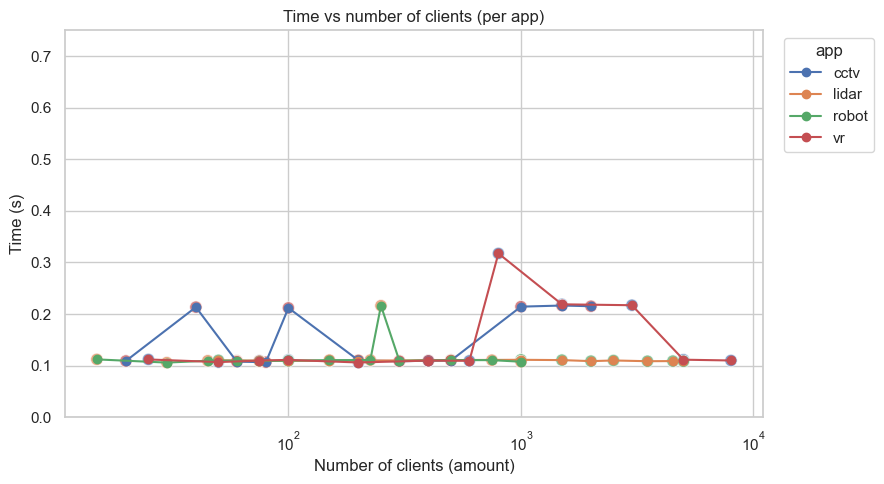

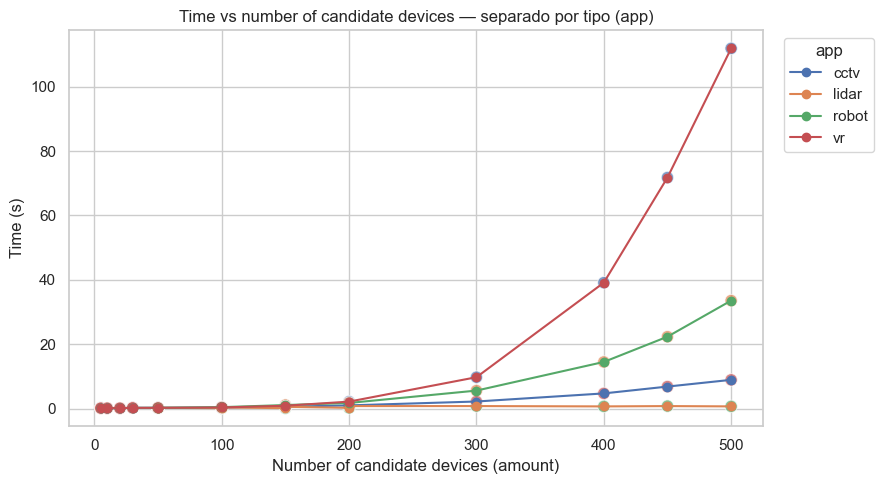

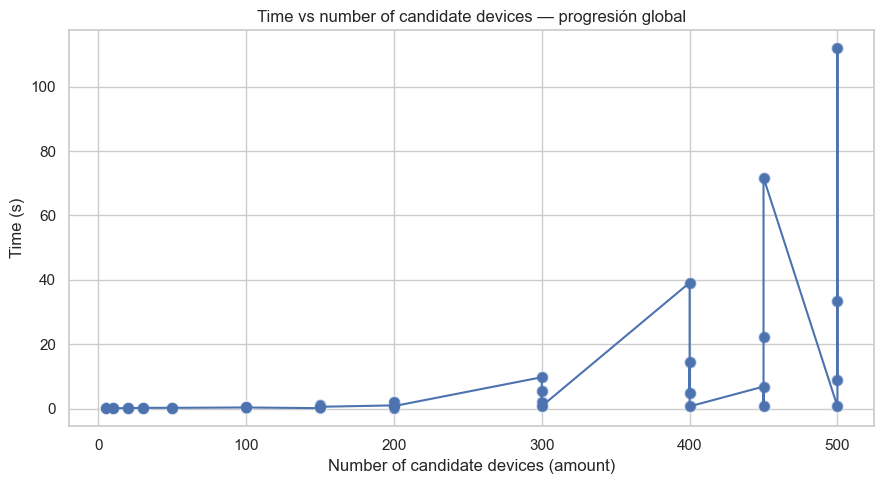

Saved figures in: results/figures


In [16]:
# 6. Display and save result figures (clients/devices progression)
import pandas as pd
import os
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style='whitegrid')

RESULTS_CSV = os.path.join(RESULTS_DIR, 'results.csv')
df = pd.read_csv(RESULTS_CSV)

# Ensure numeric time and drop invalid rows
df['time_seconds'] = pd.to_numeric(df['time_seconds'], errors='coerce')
df = df.dropna(subset=['time_seconds','scenario_id']).copy()

# Parse scenario_id expected format: size_kind_app_amount (e.g. medium_clients_lidar_1000)
parts = df['scenario_id'].astype(str).str.split('_')
df['size'] = parts.str[0].fillna('')
df['kind'] = parts.str[1].fillna('')
df['app'] = parts.str[2].fillna('')
df['amount'] = pd.to_numeric(parts.str[3], errors='coerce')

# Figures directory
figures_dir = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# 1) Clients: for ids containing 'clients' -> x = amount (clients), y = time_seconds
df_clients = df[df['kind'].str.contains('clients', na=False)].copy()
plt.figure(figsize=(9,5))
# connect points per app (scenario type) for readability
for app, g in df_clients.groupby('app'):
    g_sorted = g.sort_values('amount')
    plt.plot(g_sorted['amount'], g_sorted['time_seconds'], marker='o', linestyle='-', label=app)
sns.scatterplot(data=df_clients, x='amount', y='time_seconds', hue='app', legend=False, s=80, alpha=0.7)
plt.xscale('log') if (df_clients['amount']>0).any() and df_clients['amount'].max()/df_clients['amount'].min()>20 else None
plt.xlabel('Number of clients (amount)')
plt.ylabel('Time (s)')
plt.title('Time vs number of clients (per app)')
plt.ylim(0, 0.75)
plt.legend(title='app', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_vs_n_clients_by_app.png'))
plt.show()

# 2) Devices: for ids containing 'devices' -> x = amount (candidate devices), y = time_seconds
df_devices = df[df['kind'].str.contains('devices', na=False)].copy()
plt.figure(figsize=(9,5))
# connect points that share 'app' (tipo de escenario)
for app, g in df_devices.groupby('app'):
    g_sorted = g.sort_values('amount')
    plt.plot(g_sorted['amount'], g_sorted['time_seconds'], marker='o', linestyle='-', label=app)
sns.scatterplot(data=df_devices, x='amount', y='time_seconds', hue='app', legend=False, s=80, alpha=0.7)
plt.xlabel('Number of candidate devices (amount)')
plt.ylabel('Time (s)')
plt.title('Time vs number of candidate devices — separado por tipo (app)')
plt.legend(title='app', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_vs_num_devices_by_app.png'))
plt.show()

# 3) Devices (global progression): connect all device points in order of amount (no separación por app)
plt.figure(figsize=(9,5))
df_devices_sorted = df_devices.sort_values('amount')
plt.plot(df_devices_sorted['amount'], df_devices_sorted['time_seconds'], marker='o', linestyle='-')
sns.scatterplot(data=df_devices_sorted, x='amount', y='time_seconds', color='C0', s=80, alpha=0.7)
plt.xlabel('Number of candidate devices (amount)')
plt.ylabel('Time (s)')
plt.title('Time vs number of candidate devices — progresión global')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_vs_num_devices_global.png'))
plt.show()

print('Saved figures in:', figures_dir)

# Debug helpers

In [12]:
pricing_path = os.path.join(TOPOLOGIES_DIR, topologies["large_devices_vr_300"], "problem_instance_pricing.yml")

print(f"Pricing path: {pricing_path}")

pricing = pdsa.utils.yaml_to_pricing_proto(pricing_path, Pricing)

pdsa.utils.find_identical_addons(pricing)



Pricing path: synthetic-dataset/synthetic-topologies/3683d0ab-61df-469d-bff0-50fb60b7a31a/problem_instance_pricing.yml


[]